In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
pd.set_option("display.max_rows", None)
sns.set_theme(style="whitegrid", font="serif", font_scale=0.6)

In [3]:
gold_df = pd.read_parquet(
    r"C:\MSDA\D610 (capstone)\Airport Congestion Prediction System\Task 2\Airport Congestion Prediction System\data\output\transformed\airport_congestion_gold"
)

### SECTION 1 - Dataset Overview

##### Row Counts

In [4]:
print(f"Total rows: {len(gold_df)}\n")

unique_iata_code = gold_df['iata_code'].unique()
print(f"Total unique airports:\n{len(unique_iata_code)}")
print(f"Unique airports:\n{unique_iata_code}\n")

unique_years = gold_df['year'].unique()
print(f"Total unique years:\n{len(unique_years)}")
print(f"Unique years:\n{unique_years}\n")

unique_year_months = sorted(
    (gold_df['year'].astype(str) + "-" + gold_df['month'].astype(str)).unique()
)
print(f"Unique year-month combinations: {unique_year_months}\n")

count_by_year = gold_df['year'].value_counts()
print(f"Total rows per year: {count_by_year}\n")

count_by_iata = gold_df['iata_code'].value_counts()
print(f"Total rows per airport: {count_by_iata}")

Total rows: 11020

Total unique airports:
337
Unique airports:
['ABI' 'ABQ' 'ABR' 'ABY' 'ACK' 'ADK' 'ADQ' 'AGS' 'ALB' 'ALO' 'ANC' 'APN'
 'ART' 'ASE' 'ATL' 'ATW' 'AZO' 'BDL' 'BET' 'BFL' 'BGM' 'BGR' 'BHM' 'BIL'
 'BIS' 'BKG' 'BLI' 'BMI' 'BNA' 'BOI' 'BOS' 'BPT' 'BQK' 'BQN' 'BRD' 'BRO'
 'BTM' 'BTR' 'BTV' 'BUF' 'BUR' 'BWI' 'BZN' 'CAE' 'CAK' 'CEC' 'CHA' 'CHS'
 'CIC' 'CIU' 'CLD' 'CLE' 'CLT' 'CMH' 'CMI' 'CMX' 'COD' 'COU' 'CPR' 'CRP'
 'CRW' 'CSG' 'CVG' 'CWA' 'DAB' 'DAL' 'DAY' 'DCA' 'DEN' 'DFW' 'DHN' 'DLH'
 'DRO' 'DRT' 'DSM' 'DTW' 'EAU' 'ECP' 'EGE' 'EKO' 'ELM' 'ERI' 'ESC' 'EUG'
 'EVV' 'EWN' 'EWR' 'FAR' 'FAT' 'FCA' 'FLG' 'FLL' 'FSD' 'FSM' 'FWA' 'GCC'
 'GCK' 'GEG' 'GGG' 'GNV' 'GPT' 'GRB' 'GRI' 'GRK' 'GRR' 'GSO' 'GSP' 'GST'
 'GTF' 'GTR' 'GUC' 'GUM' 'HIB' 'HLN' 'HNL' 'HOU' 'HPN' 'HRL' 'IAD' 'IAH'
 'ICT' 'ILM' 'IMT' 'INL' 'ISP' 'ITH' 'ITO' 'IYK' 'JAC' 'JAN' 'JFK' 'JLN'
 'KOA' 'KTN' 'LAN' 'LAS' 'LAX' 'LFT' 'LGA' 'LGB' 'LIH' 'LIT' 'LMT' 'LNK'
 'LRD' 'LWS' 'MAF' 'MBS' 'MCI' 'MCO' 'MDT' 'MDW' 'MEM' 'MFE' 

##### Schema Inspection

In [5]:
gold_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11020 entries, 0 to 11019
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   iata_code                  11020 non-null  object  
 1   month                      11020 non-null  int32   
 2   total_flights              11020 non-null  int64   
 3   avg_departure_delay        11020 non-null  float64 
 4   avg_arrival_delay          11018 non-null  float64 
 5   delay_rate                 11020 non-null  float64 
 6   cancellation_rate          11020 non-null  float64 
 7   avg_carrier_delay          11020 non-null  float64 
 8   avg_weather_delay          11020 non-null  float64 
 9   avg_nas_delay              11020 non-null  float64 
 10  avg_security_delay         11020 non-null  float64 
 11  avg_late_aircraft_delay    11020 non-null  float64 
 12  avg_taxi_out_time          11020 non-null  float64 
 13  avg_taxi_in_time           1101

### SECTION 2 - Data Quality

##### Duplicate Composite Primary Key Check

In [6]:
composite_pk = ["iata_code", "year", "month"]

duplicate_keys = (
    gold_df
    .groupby(composite_pk)
    .size()
    .reset_index(name="count")
)

duplicate_keys[duplicate_keys["count"] > 1]

C:\Users\kyuen\AppData\Local\Temp\ipykernel_22236\2053627411.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(composite_pk)


,iata_code,year,month,count


##### Null Analysis

In [7]:
null_count = gold_df.isna().sum()
print(f"Null count:\n{null_count}")

Null count:
iata_code                       0
month                           0
total_flights                   0
avg_departure_delay             0
avg_arrival_delay               2
delay_rate                      0
cancellation_rate               0
avg_carrier_delay               0
avg_weather_delay               0
avg_nas_delay                   0
avg_security_delay              0
avg_late_aircraft_delay         0
avg_taxi_out_time               0
avg_taxi_in_time                1
avg_total_taxi_time             1
total_passenger_count        4840
avg_wait_time_minutes        7897
avg_temperature              8243
total_precipitation          8232
total_snowfall               9083
passenger_to_flight_ratio    4840
year                            0
dtype: int64


In [8]:
columns = [
    'avg_arrival_delay',
    'avg_taxi_in_time',
    'avg_total_taxi_time',
    'total_passenger_count',
    'avg_wait_time_minutes',
    'avg_temperature',
    'total_precipitation',
    'total_snowfall',
    'passenger_to_flight_ratio'
]

for column in columns:
    null_count = gold_df.groupby('year')[column].apply(lambda x: x.isnull().sum())
    print(f"Null count by {column}:\n{null_count}\n")

Null count by avg_arrival_delay:
year
2013    2
2014    0
2015    0
Name: avg_arrival_delay, dtype: int64

Null count by avg_taxi_in_time:
year
2013    1
2014    0
2015    0
Name: avg_taxi_in_time, dtype: int64

Null count by avg_total_taxi_time:
year
2013    1
2014    0
2015    0
Name: avg_total_taxi_time, dtype: int64

Null count by total_passenger_count:
year
2013    3634
2014    1047
2015     159
Name: total_passenger_count, dtype: int64

Null count by avg_wait_time_minutes:
year
2013    2605
2014    2642
2015    2650
Name: avg_wait_time_minutes, dtype: int64

Null count by avg_temperature:
year
2013    2693
2014    2763
2015    2787
Name: avg_temperature, dtype: int64

Null count by total_precipitation:
year
2013    2689
2014    2757
2015    2786
Name: total_precipitation, dtype: int64

Null count by total_snowfall:
year
2013    2966
2014    3057
2015    3060
Name: total_snowfall, dtype: int64

Null count by passenger_to_flight_ratio:
year
2013    3634
2014    1047
2015     159
Na

C:\Users\kyuen\AppData\Local\Temp\ipykernel_22236\4290377459.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  null_count = gold_df.groupby('year')[column].apply(lambda x: x.isnull().sum())


In [9]:
columns = [
    'avg_arrival_delay',
    'avg_taxi_in_time',
    'avg_total_taxi_time',
    'total_passenger_count',
    'avg_wait_time_minutes',
    'avg_temperature',
    'total_precipitation',
    'total_snowfall',
    'passenger_to_flight_ratio'
]

year_month = gold_df['year'].astype(str) + "-" + gold_df['month'].astype(str)

for column in columns:
    null_count = gold_df.groupby(year_month)[column].apply(lambda x: x.isnull().sum())
    print(f"Null count by {column}:\n{null_count}\n")

Null count by avg_arrival_delay:
2013-1     0
2013-10    0
2013-11    0
2013-12    0
2013-2     0
2013-3     0
2013-4     0
2013-5     0
2013-6     1
2013-7     0
2013-8     0
2013-9     1
2014-1     0
2014-10    0
2014-11    0
2014-12    0
2014-2     0
2014-3     0
2014-4     0
2014-5     0
2014-6     0
2014-7     0
2014-8     0
2014-9     0
2015-1     0
2015-10    0
2015-11    0
2015-12    0
2015-2     0
2015-3     0
2015-4     0
2015-5     0
2015-6     0
2015-7     0
2015-8     0
2015-9     0
Name: avg_arrival_delay, dtype: int64

Null count by avg_taxi_in_time:
2013-1     0
2013-10    0
2013-11    0
2013-12    0
2013-2     0
2013-3     0
2013-4     0
2013-5     0
2013-6     1
2013-7     0
2013-8     0
2013-9     0
2014-1     0
2014-10    0
2014-11    0
2014-12    0
2014-2     0
2014-3     0
2014-4     0
2014-5     0
2014-6     0
2014-7     0
2014-8     0
2014-9     0
2015-1     0
2015-10    0
2015-11    0
2015-12    0
2015-2     0
2015-3     0
2015-4     0
2015-5     0
2015-6     0

In [10]:
null_percentage = gold_df.isnull().mean() * 100

print(f"Null percentage:\n{round(null_percentage, 2)}")

Null percentage:
iata_code                     0.00
month                         0.00
total_flights                 0.00
avg_departure_delay           0.00
avg_arrival_delay             0.02
delay_rate                    0.00
cancellation_rate             0.00
avg_carrier_delay             0.00
avg_weather_delay             0.00
avg_nas_delay                 0.00
avg_security_delay            0.00
avg_late_aircraft_delay       0.00
avg_taxi_out_time             0.00
avg_taxi_in_time              0.01
avg_total_taxi_time           0.01
total_passenger_count        43.92
avg_wait_time_minutes        71.66
avg_temperature              74.80
total_precipitation          74.70
total_snowfall               82.42
passenger_to_flight_ratio    43.92
year                          0.00
dtype: float64


In [11]:
columns = [
    'avg_arrival_delay',
    'avg_taxi_in_time',
    'avg_total_taxi_time',
    'total_passenger_count',
    'avg_wait_time_minutes',
    'avg_temperature',
    'total_precipitation',
    'total_snowfall',
    'passenger_to_flight_ratio'
]

for column in columns:
    null_percentage = gold_df.groupby('year')[column].apply(lambda x: x.isnull().mean() * 100)
    print(f"Null percentage by {column}:\n{round(null_percentage, 2)}\n")

Null percentage by avg_arrival_delay:
year
2013    0.06
2014    0.00
2015    0.00
Name: avg_arrival_delay, dtype: float64

Null percentage by avg_taxi_in_time:
year
2013    0.03
2014    0.00
2015    0.00
Name: avg_taxi_in_time, dtype: float64

Null percentage by avg_total_taxi_time:
year
2013    0.03
2014    0.00
2015    0.00
Name: avg_total_taxi_time, dtype: float64

Null percentage by total_passenger_count:
year
2013    100.00
2014     28.43
2015      4.29
Name: total_passenger_count, dtype: float64

Null percentage by avg_wait_time_minutes:
year
2013    71.68
2014    71.73
2015    71.56
Name: avg_wait_time_minutes, dtype: float64

Null percentage by avg_temperature:
year
2013    74.11
2014    75.02
2015    75.26
Name: avg_temperature, dtype: float64

Null percentage by total_precipitation:
year
2013    74.00
2014    74.86
2015    75.24
Name: total_precipitation, dtype: float64

Null percentage by total_snowfall:
year
2013    81.62
2014    83.00
2015    82.64
Name: total_snowfall, dt

C:\Users\kyuen\AppData\Local\Temp\ipykernel_22236\3708979632.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  null_percentage = gold_df.groupby('year')[column].apply(lambda x: x.isnull().mean() * 100)


In [12]:
columns = [
    'avg_arrival_delay',
    'avg_taxi_in_time',
    'avg_total_taxi_time',
    'total_passenger_count',
    'avg_wait_time_minutes',
    'avg_temperature',
    'total_precipitation',
    'total_snowfall',
    'passenger_to_flight_ratio'
]

year_month = gold_df['year'].astype(str) + "-" + gold_df['month'].astype(str)

for column in columns:
    null_percentage = gold_df.groupby(year_month)[column].apply(lambda x: x.isnull().mean() * 100)
    print(f"Null percentage by {column}:\n{round(null_percentage, 2)}\n")

Null percentage by avg_arrival_delay:
2013-1     0.00
2013-10    0.00
2013-11    0.00
2013-12    0.00
2013-2     0.00
2013-3     0.00
2013-4     0.00
2013-5     0.00
2013-6     0.32
2013-7     0.00
2013-8     0.00
2013-9     0.35
2014-1     0.00
2014-10    0.00
2014-11    0.00
2014-12    0.00
2014-2     0.00
2014-3     0.00
2014-4     0.00
2014-5     0.00
2014-6     0.00
2014-7     0.00
2014-8     0.00
2014-9     0.00
2015-1     0.00
2015-10    0.00
2015-11    0.00
2015-12    0.00
2015-2     0.00
2015-3     0.00
2015-4     0.00
2015-5     0.00
2015-6     0.00
2015-7     0.00
2015-8     0.00
2015-9     0.00
Name: avg_arrival_delay, dtype: float64

Null percentage by avg_taxi_in_time:
2013-1     0.00
2013-10    0.00
2013-11    0.00
2013-12    0.00
2013-2     0.00
2013-3     0.00
2013-4     0.00
2013-5     0.00
2013-6     0.32
2013-7     0.00
2013-8     0.00
2013-9     0.00
2014-1     0.00
2014-10    0.00
2014-11    0.00
2014-12    0.00
2014-2     0.00
2014-3     0.00
2014-4     0.00
2014

##### Outlier Detection (IQR)

In [18]:
def detect_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    return outliers


outlier_columns = [                                  
    'avg_departure_delay',         
    'avg_arrival_delay',                    
    'avg_carrier_delay',         
    'avg_weather_delay',           
    'avg_nas_delay',               
    'avg_security_delay',          
    'avg_late_aircraft_delay',        
    'total_passenger_count',                
    'total_snowfall'         
]

for col in outlier_columns:
    outliers_delay = detect_outliers(gold_df, col)
    print(f"Number of outliers ({col}): {len(outliers_delay)}")

Number of outliers (avg_departure_delay): 423
Number of outliers (avg_arrival_delay): 486
Number of outliers (avg_carrier_delay): 517
Number of outliers (avg_weather_delay): 1203
Number of outliers (avg_nas_delay): 522
Number of outliers (avg_security_delay): 1621
Number of outliers (avg_late_aircraft_delay): 428
Number of outliers (total_passenger_count): 948
Number of outliers (total_snowfall): 340


### SECTION 3 - Descriptive Statistics

##### Mean, Median, and Mode

In [13]:
columns = [                     
    'total_flights',               
    'avg_departure_delay',         
    'avg_arrival_delay',           
    'delay_rate',                  
    'cancellation_rate',           
    'avg_carrier_delay',         
    'avg_weather_delay',           
    'avg_nas_delay',               
    'avg_security_delay',          
    'avg_late_aircraft_delay',     
    'avg_taxi_out_time',           
    'avg_taxi_in_time',            
    'avg_total_taxi_time',         
    'total_passenger_count',       
    'avg_wait_time_minutes',       
    'avg_temperature',             
    'total_precipitation',         
    'total_snowfall',              
    'passenger_to_flight_ratio',   
]

means = [gold_df[column].mean() for column in columns]
medians = [gold_df[column].median() for column in columns]
modes = [gold_df[column].mode() for column in columns]

print("Mean")
for column, mean in zip(columns, means):
    print(f"{column}: {mean}")

print("\nMedian")
for column, median in zip(columns, medians):
    print(f"{column}: {median}")

print("\nMode")
for column, mode in zip(columns, modes):
    print(f"{column}: {mode}")

Mean
total_flights: 1095.8631578947368
avg_departure_delay: 7.687095281306716
avg_arrival_delay: 5.040839535305863
delay_rate: 0.1631814882032668
cancellation_rate: 0.026691470054446467
avg_carrier_delay: 3.09109165154265
avg_weather_delay: 0.5071315789473685
avg_nas_delay: 2.680138838475499
avg_security_delay: 0.03284664246823957
avg_late_aircraft_delay: 4.950035390199636
avg_taxi_out_time: 13.534942831215972
avg_taxi_in_time: 8.27349941010981
avg_total_taxi_time: 21.80893910518196
total_passenger_count: 134560.76925566344
avg_wait_time_minutes: 4.980249759846301
avg_temperature: 13.561339575081021
total_precipitation: 81.92216642754663
total_snowfall: 75.1115126484254
passenger_to_flight_ratio: 150.6029417475728

Median
total_flights: 183.0
avg_departure_delay: 6.89
avg_arrival_delay: 4.02
delay_rate: 0.16
cancellation_rate: 0.01
avg_carrier_delay: 2.34
avg_weather_delay: 0.09
avg_nas_delay: 2.1
avg_security_delay: 0.0
avg_late_aircraft_delay: 4.29
avg_taxi_out_time: 13.06
avg_taxi_i

##### Standard Deviation & Cofficient of Variation (CV)

In [14]:
columns = [                     
    'total_flights',               
    'avg_departure_delay',         
    'avg_arrival_delay',           
    'delay_rate',                  
    'cancellation_rate',           
    'avg_carrier_delay',         
    'avg_weather_delay',           
    'avg_nas_delay',               
    'avg_security_delay',          
    'avg_late_aircraft_delay',     
    'avg_taxi_out_time',           
    'avg_taxi_in_time',            
    'avg_total_taxi_time',         
    'total_passenger_count',       
    'avg_wait_time_minutes',       
    'avg_temperature',             
    'total_precipitation',         
    'total_snowfall',              
    'passenger_to_flight_ratio',   
]

column_std_d = {}

for column in columns:
    std_d = gold_df[column].std()

    column_std_d[column] = std_d

###### Standard Deviation

In [15]:
# Standard deviation measures the variability or dispersion of a feature around its mean. 
# High standard deviation = values vary a lot
for column, std_d in column_std_d.items():
    print(f"Standard Deviation ({column}):\n{std_d}")

# Interpretation:
## example
### total_flights - the number of flights varies substantially from the average number of flights because of seasonality, large airports vs small airports
### avg_departure_delay - values less vary

Standard Deviation (total_flights):
2635.728687600857
Standard Deviation (avg_departure_delay):
12.391719589916953
Standard Deviation (avg_arrival_delay):
13.270409818736617
Standard Deviation (delay_rate):
0.0894578649122783
Standard Deviation (cancellation_rate):
0.04107213113869532
Standard Deviation (avg_carrier_delay):
9.425688159199357
Standard Deviation (avg_weather_delay):
1.4154823788210238
Standard Deviation (avg_nas_delay):
3.3790637826405137
Standard Deviation (avg_security_delay):
0.5019354319618923
Standard Deviation (avg_late_aircraft_delay):
4.698747084712549
Standard Deviation (avg_taxi_out_time):
3.495450684035641
Standard Deviation (avg_taxi_in_time):
2.4533268735493436
Standard Deviation (avg_total_taxi_time):
4.502932348661866
Standard Deviation (total_passenger_count):
333503.92522059014
Standard Deviation (avg_wait_time_minutes):
8.491231227160297
Standard Deviation (avg_temperature):
10.24168769963626
Standard Deviation (total_precipitation):
76.15228009211158
S

###### Coefficient of Variation (CV)

In [16]:
# Putting it together to interpret variability between columns 
# std / mean = CV

# | CV Range  | Interpretation             |
# | --------- | -------------------------- |
# | < 0.1     | Very low variability       |
# | 0.1 – 0.3 | Low variability            |
# | 0.3 – 0.5 | Moderate variability       |
# | 0.5 – 1.0 | High variability           |
# | > 1.0     | Extremely high variability |

for column, std_d in column_std_d.items():
    mean = gold_df[column].mean()
    cv = std_d / mean
    print(f"Coefficient of Variation ({column}): {cv}")

# example
## total_flights - values greatly fluctuate
## avg_total_taxi_time - values tightly clustered around the mean

Coefficient of Variation (total_flights): 2.405162240023067
Coefficient of Variation (avg_departure_delay): 1.6120158702924918
Coefficient of Variation (avg_arrival_delay): 2.632579300688136
Coefficient of Variation (delay_rate): 0.5482108656886695
Coefficient of Variation (cancellation_rate): 1.53877366270627
Coefficient of Variation (avg_carrier_delay): 3.049307242150307
Coefficient of Variation (avg_weather_delay): 2.791154086202008
Coefficient of Variation (avg_nas_delay): 1.2607793798333868
Coefficient of Variation (avg_security_delay): 15.281179269608124
Coefficient of Variation (avg_late_aircraft_delay): 0.9492350487059947
Coefficient of Variation (avg_taxi_out_time): 0.25825381958570204
Coefficient of Variation (avg_taxi_in_time): 0.2965283191476993
Coefficient of Variation (avg_total_taxi_time): 0.20647186582275967
Coefficient of Variation (total_passenger_count): 2.478463277710145
Coefficient of Variation (avg_wait_time_minutes): 1.7049810022825744
Coefficient of Variation (a

##### Percentile Analysis

In [17]:
numeric_cols = gold_df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    print(f"\n{col}")
    print(
        gold_df[col].quantile(
            [0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
        )
    )


month
0.25     4.0
0.50     7.0
0.75     9.0
0.90    11.0
0.95    12.0
0.99    12.0
Name: month, dtype: float64

total_flights
0.25       53.00
0.50      183.00
0.75      673.50
0.90     3038.40
0.95     6195.75
0.99    13284.29
Name: total_flights, dtype: float64

avg_departure_delay
0.25     2.7000
0.50     6.8900
0.75    11.3000
0.90    16.5600
0.95    20.8010
0.99    35.4753
Name: avg_departure_delay, dtype: float64

avg_arrival_delay
0.25    -0.5900
0.50     4.0200
0.75     9.1775
0.90    15.4230
0.95    20.6460
0.99    36.2315
Name: avg_arrival_delay, dtype: float64

delay_rate
0.25    0.11
0.50    0.16
0.75    0.21
0.90    0.26
0.95    0.31
0.99    0.44
Name: delay_rate, dtype: float64

cancellation_rate
0.25    0.00
0.50    0.01
0.75    0.03
0.90    0.07
0.95    0.10
0.99    0.19
Name: cancellation_rate, dtype: float64

avg_carrier_delay
0.25     0.9000
0.50     2.3400
0.75     3.8500
0.90     5.8400
0.95     8.0305
0.99    17.1581
Name: avg_carrier_delay, dtype: float64

avg_

##### Skewness

In [19]:
# Is data balanced around the mean? Any outliers? Any extreme values pull the distribution left or right?
#
# | Skewness Value | Interpretation          |
# | -------------- | ----------------------- |
# | ≈ 0            | symmetric / normal-like |
# | -0.5 to 0.5    | approximately symmetric |
# | 0.5 to 1       | moderately skewed       |
# | > 1            | highly skewed           |
# | < -1           | highly left-skewed      |


skew_values = gold_df.skew(numeric_only=True)
print(f"Skewness\n{skew_values}")

# Interpretation:
## avg_departure_delay - right-skewed = most airports/months have normal departure delays, with only a few airports/months have extreme delays

Skewness
month                         0.001842
total_flights                 4.622113
avg_departure_delay          33.258054
avg_arrival_delay            27.667586
delay_rate                    1.828976
cancellation_rate             4.284394
avg_carrier_delay            76.890031
avg_weather_delay             8.348674
avg_nas_delay                24.768129
avg_security_delay           32.403858
avg_late_aircraft_delay       9.149964
avg_taxi_out_time             0.987887
avg_taxi_in_time              1.854503
avg_total_taxi_time           0.420815
total_passenger_count         4.326552
avg_wait_time_minutes         7.134393
avg_temperature              -0.641764
total_precipitation           1.755371
total_snowfall                2.979061
passenger_to_flight_ratio    28.990583
dtype: float64


##### Min and Max

In [22]:
columns = [col for col in columns if col != "month"]

for col in columns:
    print(f"Max ({col}): {gold_df[col].max()}")
    print(f"Min ({col}): {gold_df[col].min()}\n")

Max (total_flights): 32268
Min (total_flights): 1

Max (avg_departure_delay): 879.0
Min (avg_departure_delay): -27.0

Max (avg_arrival_delay): 880.0
Min (avg_arrival_delay): -27.25

Max (delay_rate): 1.0
Min (delay_rate): 0.0

Max (cancellation_rate): 0.78
Min (cancellation_rate): 0.0

Max (avg_carrier_delay): 891.5
Min (avg_carrier_delay): 0.0

Max (avg_weather_delay): 28.67
Min (avg_weather_delay): 0.0

Max (avg_nas_delay): 214.5
Min (avg_nas_delay): 0.0

Max (avg_security_delay): 23.25
Min (avg_security_delay): 0.0

Max (avg_late_aircraft_delay): 155.17
Min (avg_late_aircraft_delay): 0.0

Max (avg_taxi_out_time): 46.0
Min (avg_taxi_out_time): 1.0

Max (avg_taxi_in_time): 40.84
Min (avg_taxi_in_time): 2.0

Max (avg_total_taxi_time): 57.08
Min (avg_total_taxi_time): 5.0

Max (total_passenger_count): 3442080.0
Min (total_passenger_count): 47.0

Max (avg_wait_time_minutes): 145.5
Min (avg_wait_time_minutes): 1.0

Max (avg_temperature): 31.17
Min (avg_temperature): -16.76

Max (total_pre

### SECTION 4 - Univariate Analysis

##### Histograms

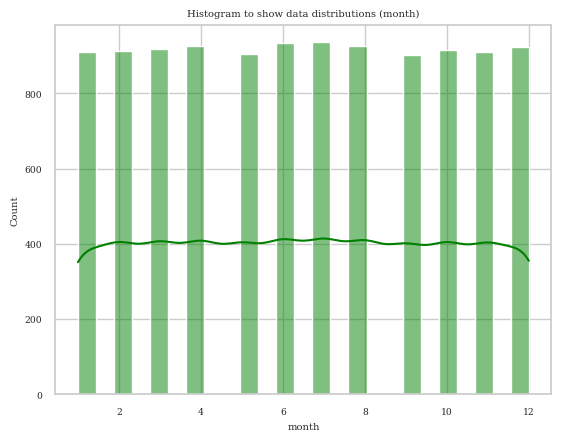

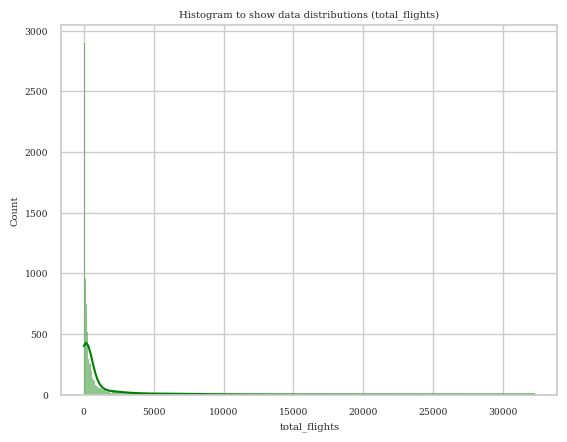

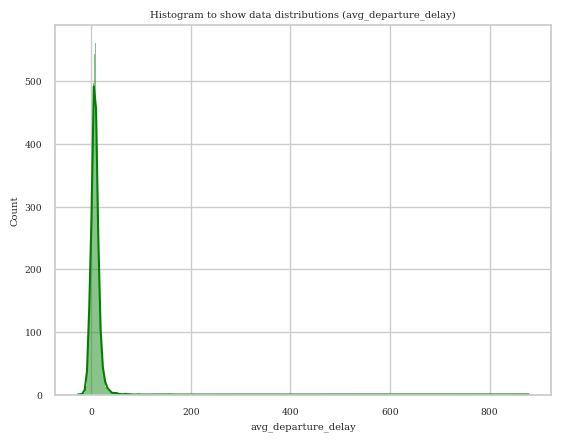

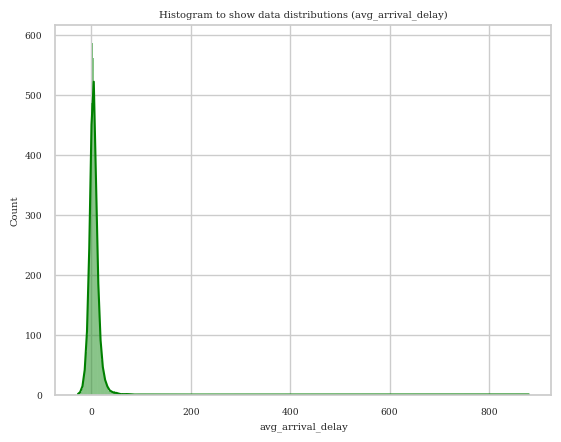

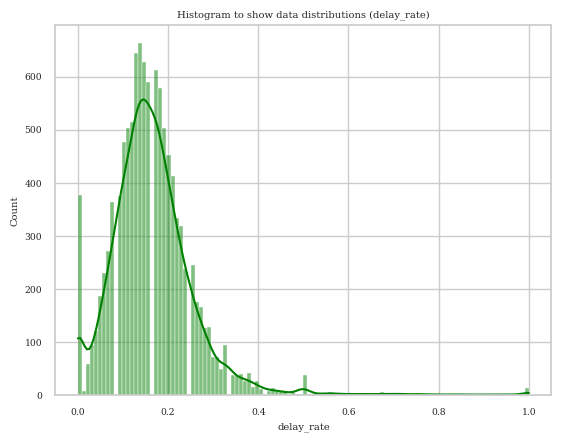

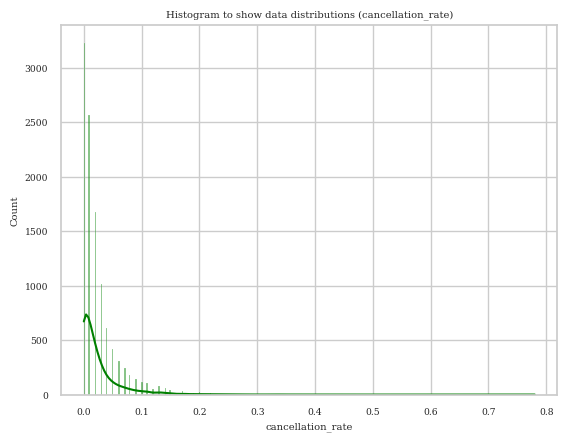

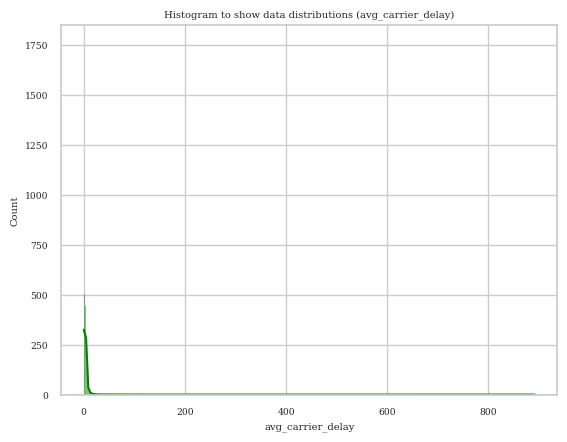

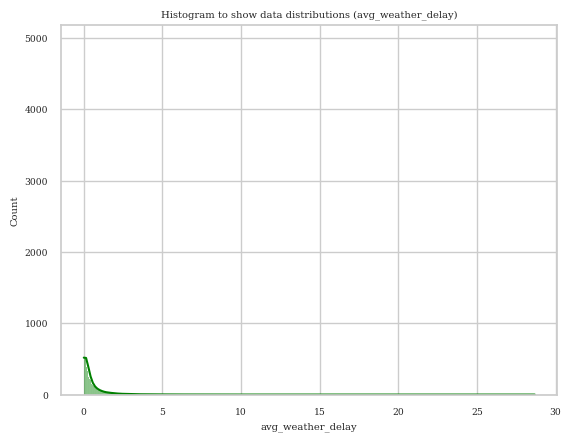

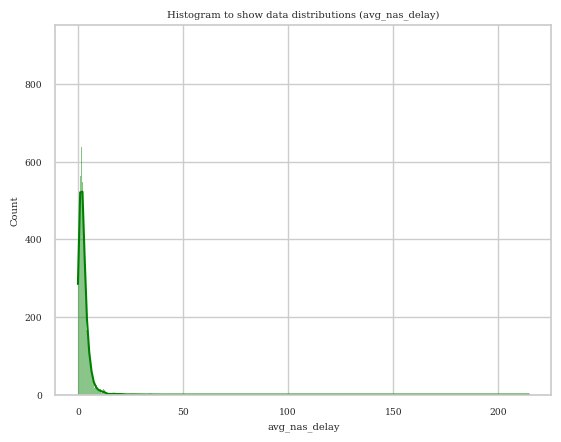

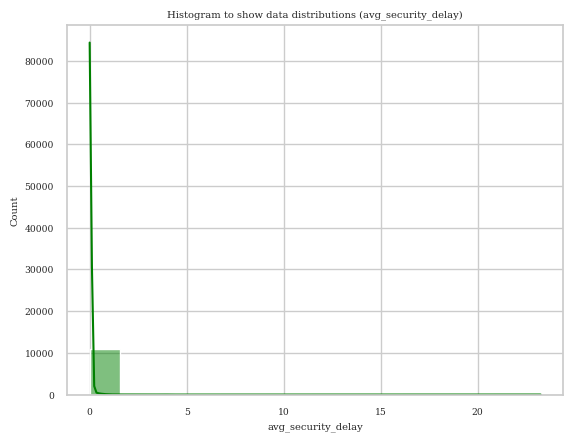

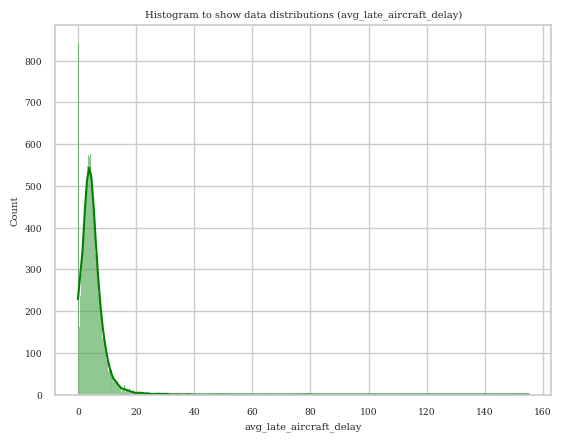

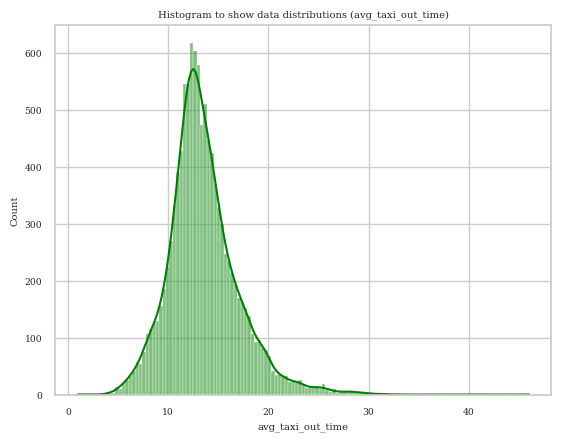

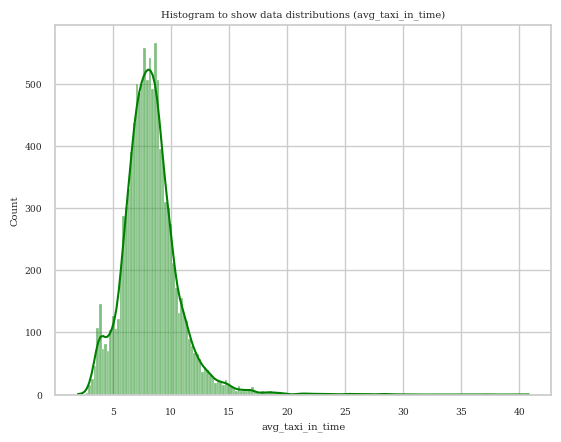

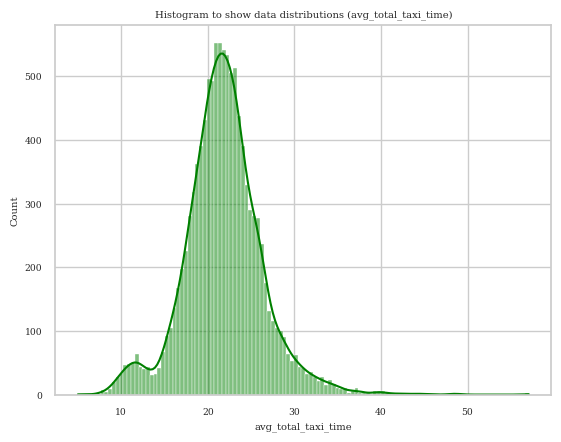

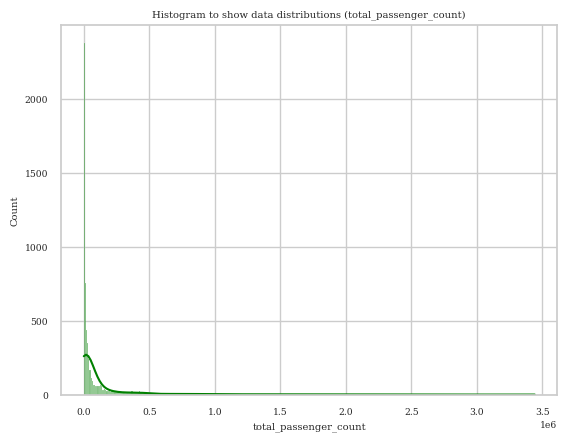

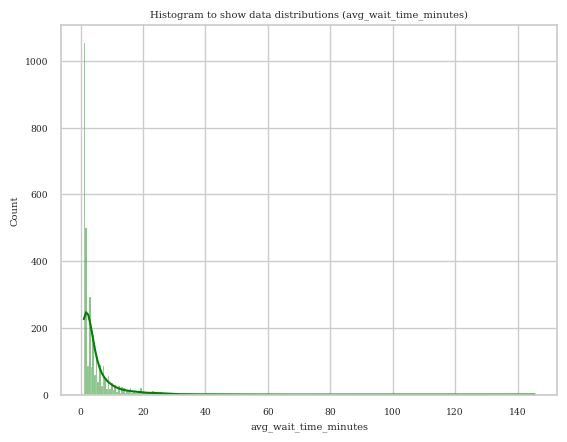

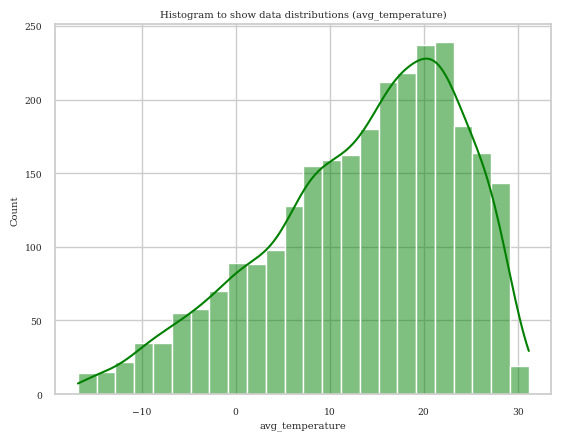

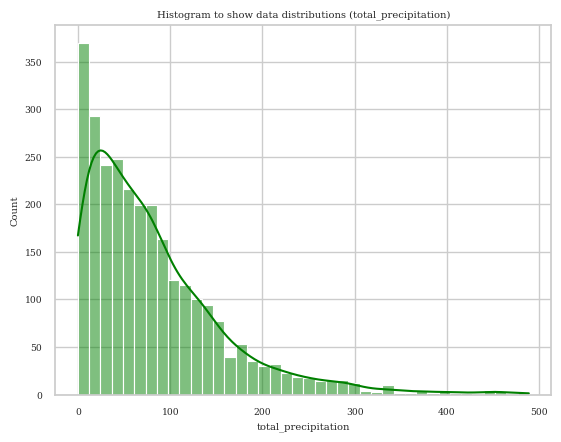

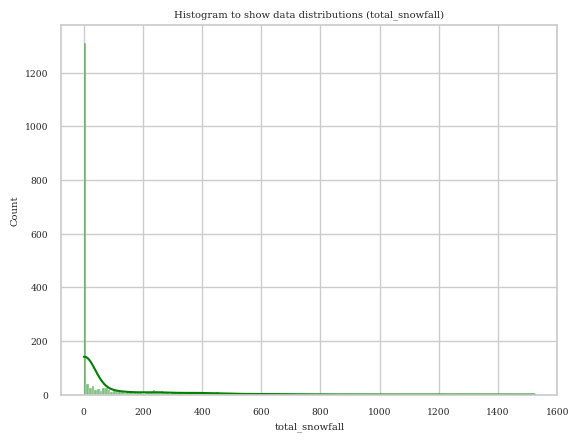

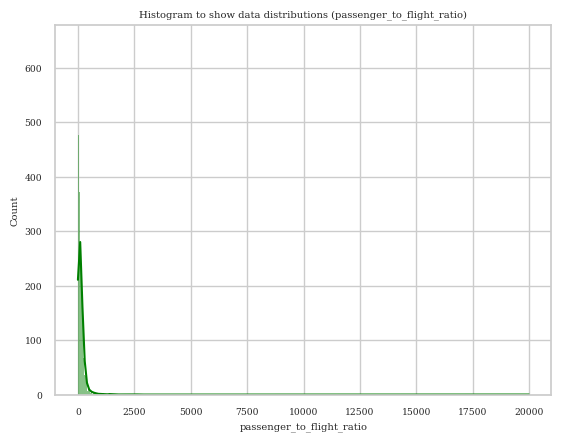

In [20]:
columns = ["month"] + columns

for col in columns:
    sns.histplot(gold_df[col], kde=True, color='green')
    plt.title(f"Histogram to show data distributions ({col})")
    plt.show()

##### Box Plots

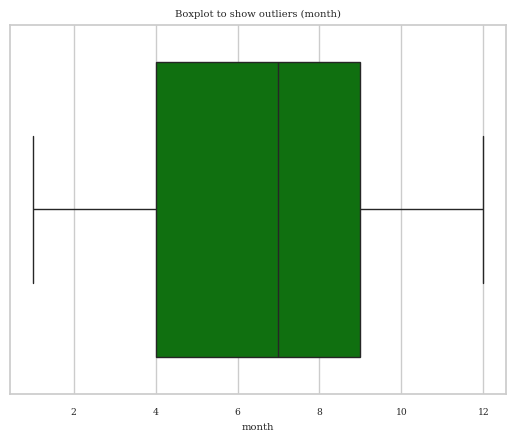

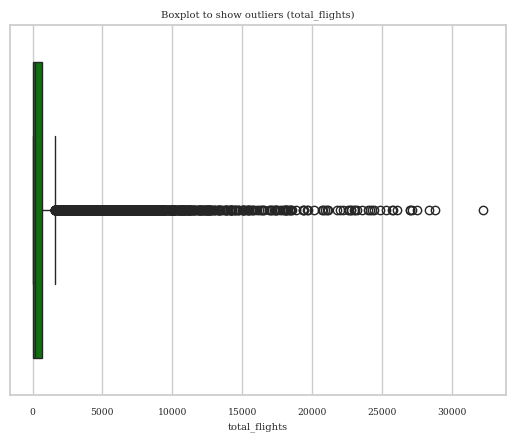

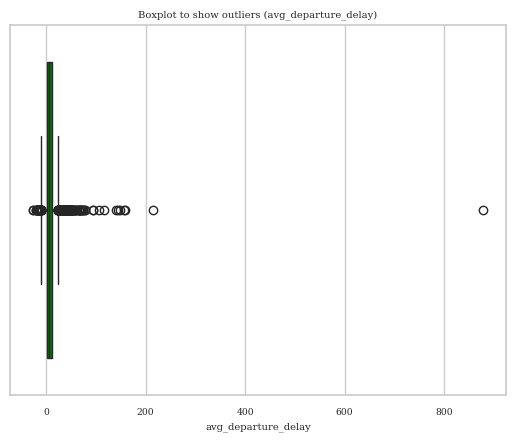

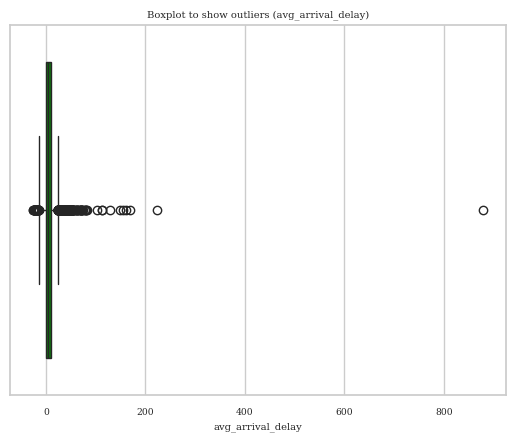

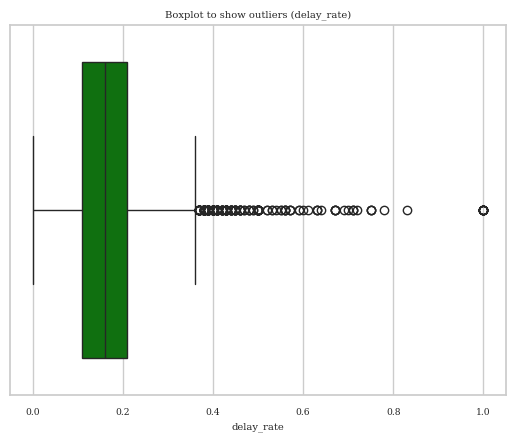

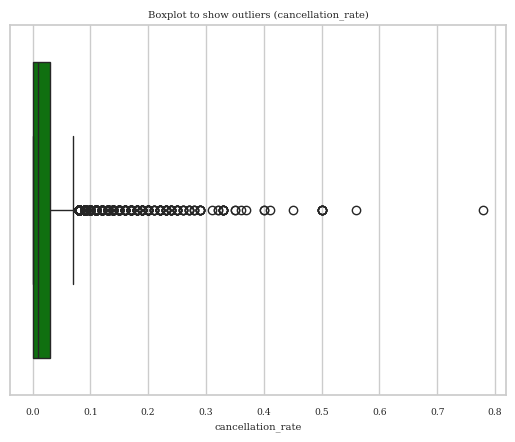

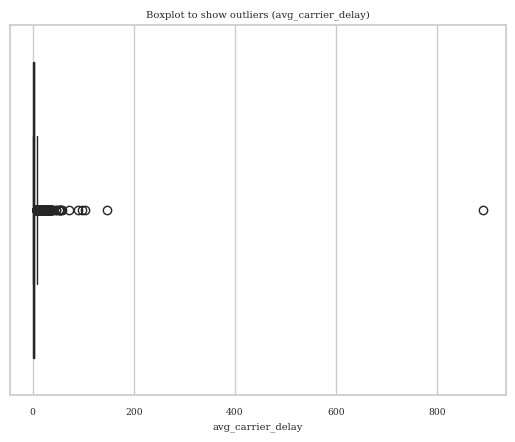

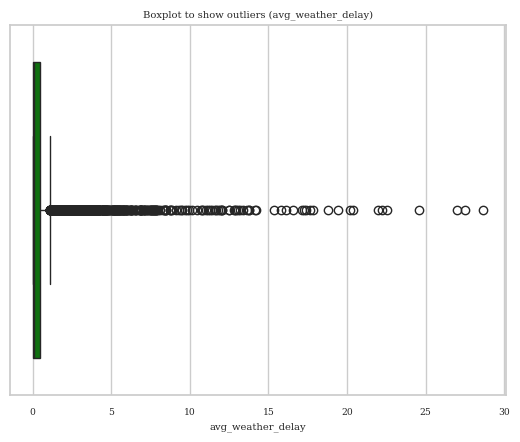

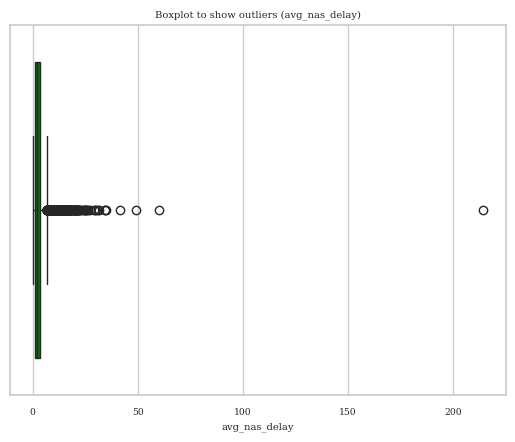

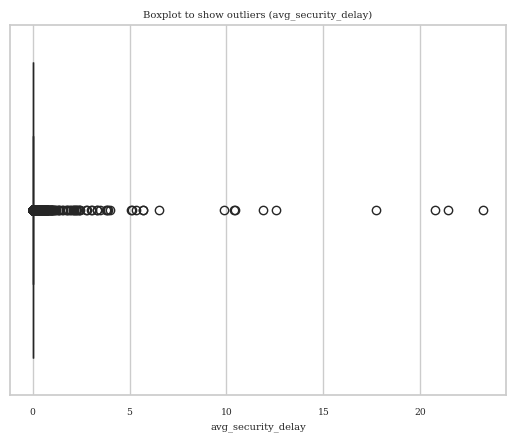

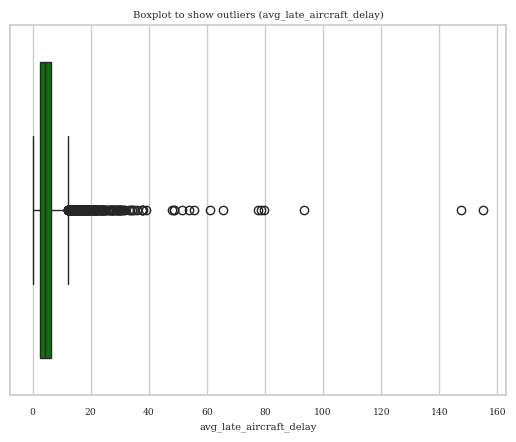

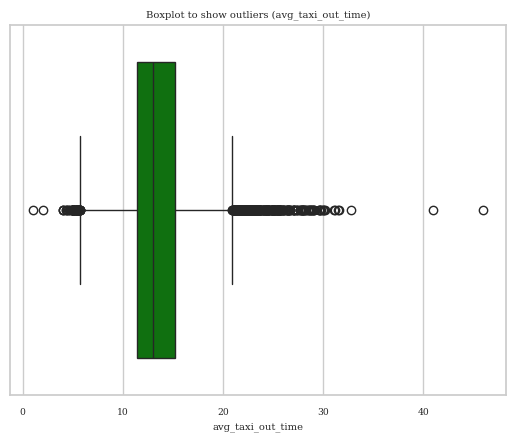

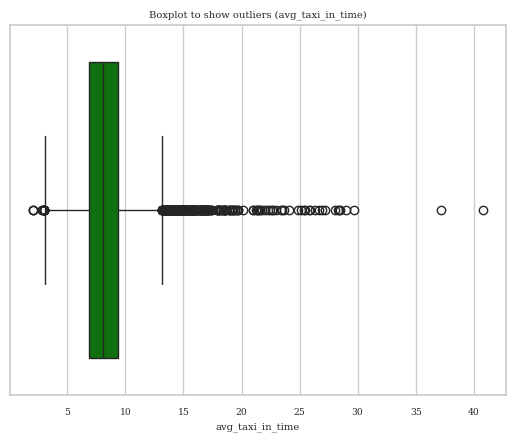

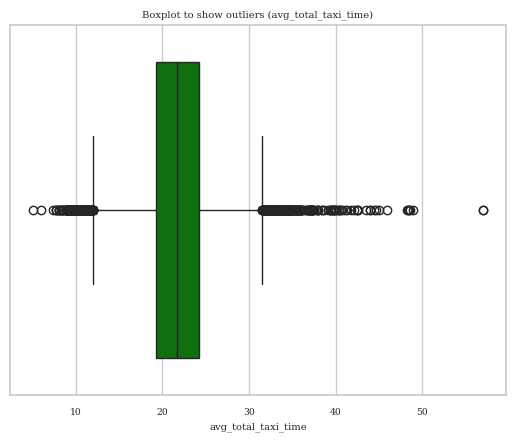

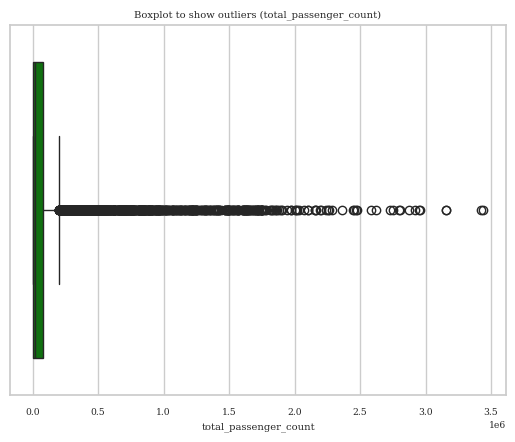

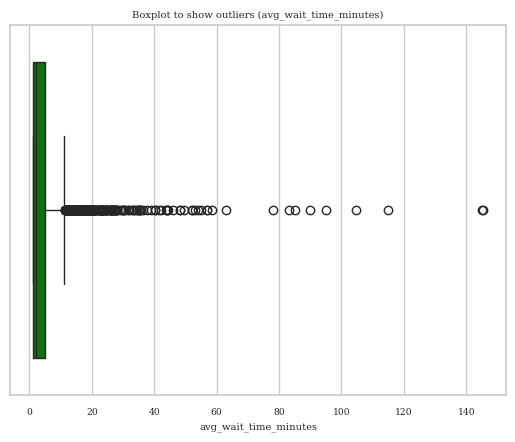

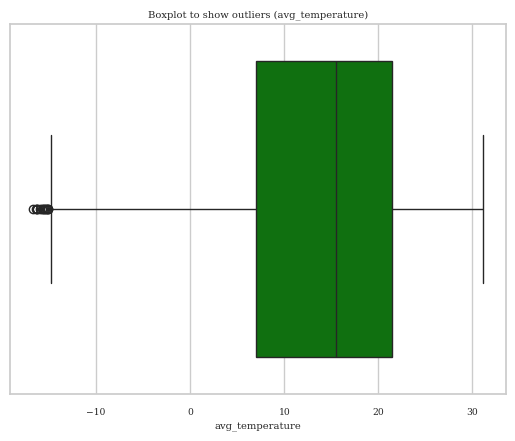

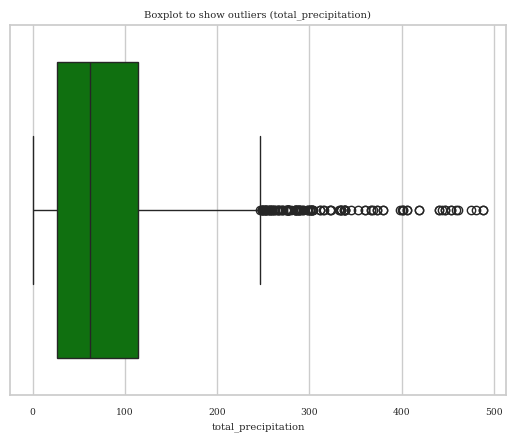

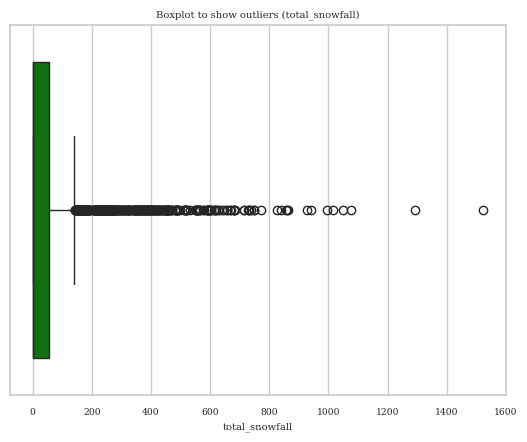

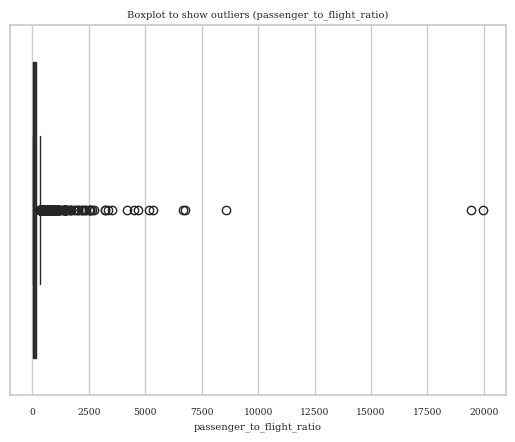

In [21]:
for col in columns:
    sns.boxplot(x=gold_df[col], color='green')
    plt.title(f"Boxplot to show outliers ({col})")
    plt.show()

### SECTION 5 - Bivariate Analysis

##### Scatterplot

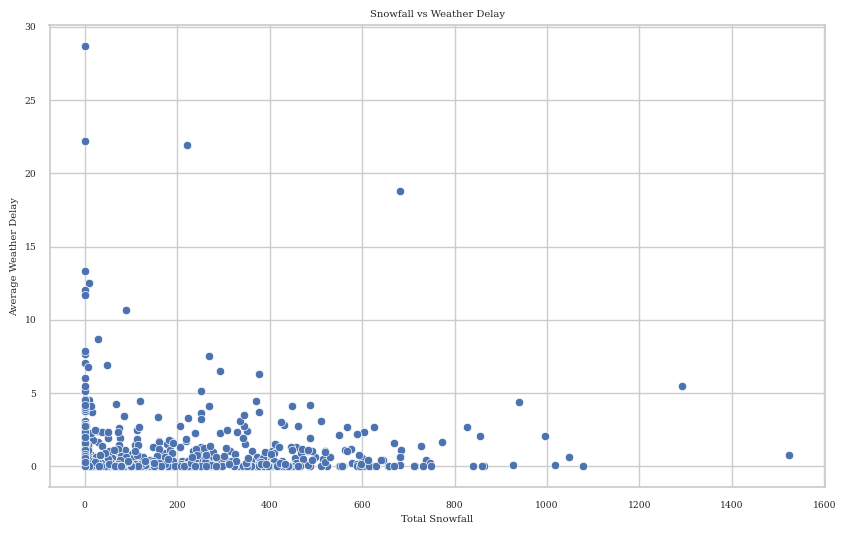

In [38]:
# Snowfall vs Weather Delay

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=gold_df,
    x="total_snowfall",
    y="avg_weather_delay"
)

plt.title("Snowfall vs Weather Delay")

plt.xlabel("Total Snowfall")
plt.ylabel("Average Weather Delay")

plt.show()

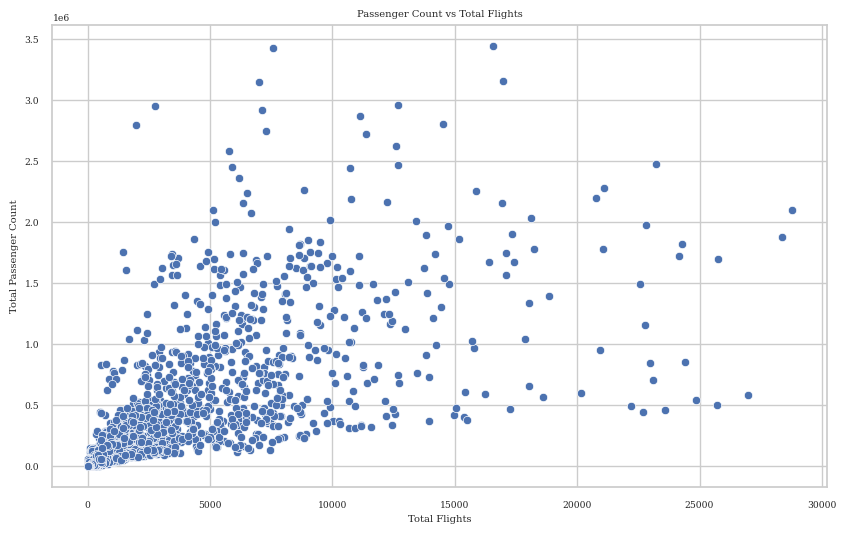

In [39]:
# Passenger Count vs Total Flights

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=gold_df,
    x="total_flights",
    y="total_passenger_count"
)

plt.title("Passenger Count vs Total Flights")

plt.xlabel("Total Flights")
plt.ylabel("Total Passenger Count")

plt.show()

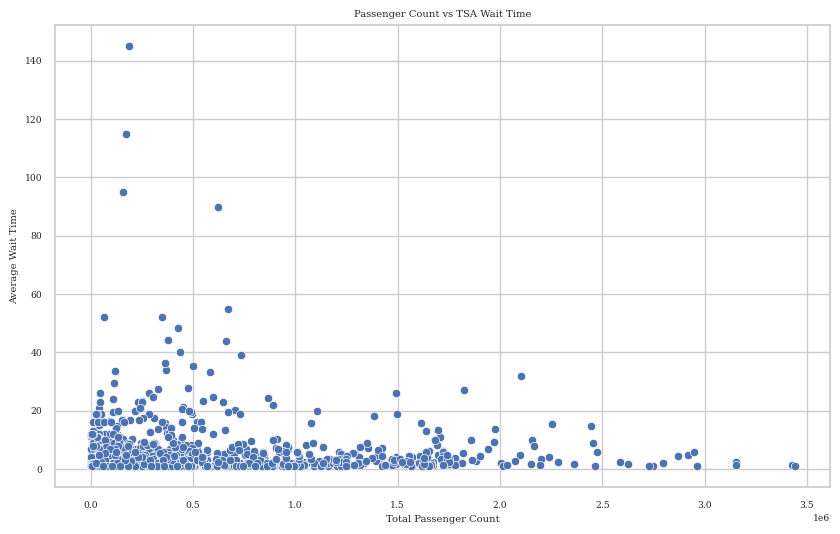

In [40]:
# Passenger Count vs TSA Wait Time

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=gold_df,
    x="total_passenger_count",
    y="avg_wait_time_minutes"
)

plt.title("Passenger Count vs TSA Wait Time")

plt.xlabel("Total Passenger Count")
plt.ylabel("Average Wait Time")

plt.show()

##### Heatmap

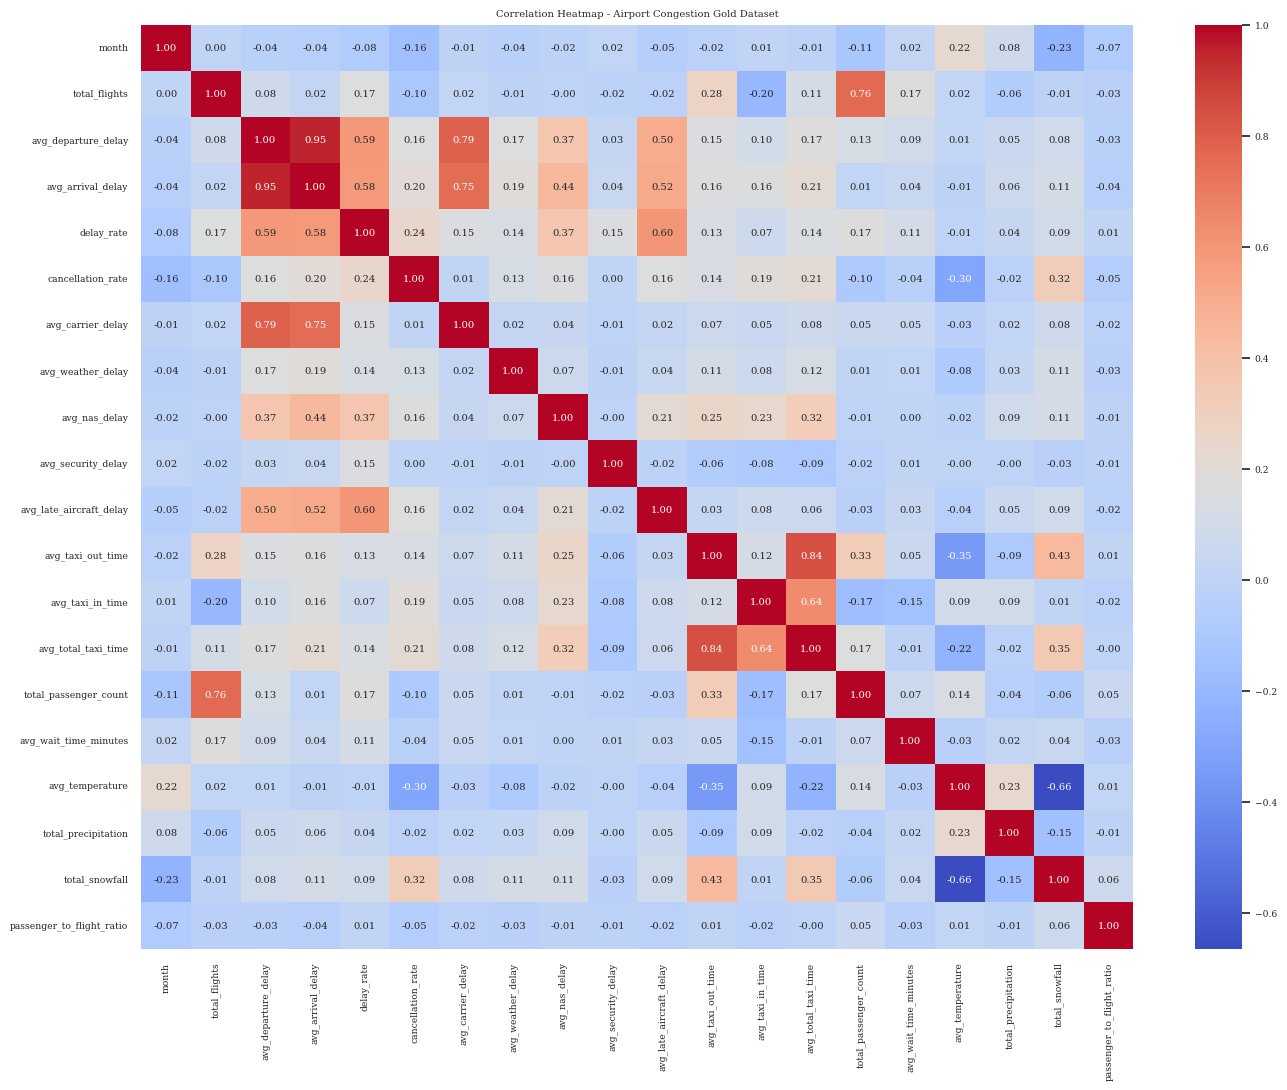

In [35]:
# Full correlation heatmap

# | Color       | Interpretation              |
# | ----------- | --------------------------- |
# | dark red    | strong positive correlation |
# | dark blue   | strong negative correlation |
# | light/white | weak correlation            |


plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap - Airport Congestion Gold Dataset")

plt.show()

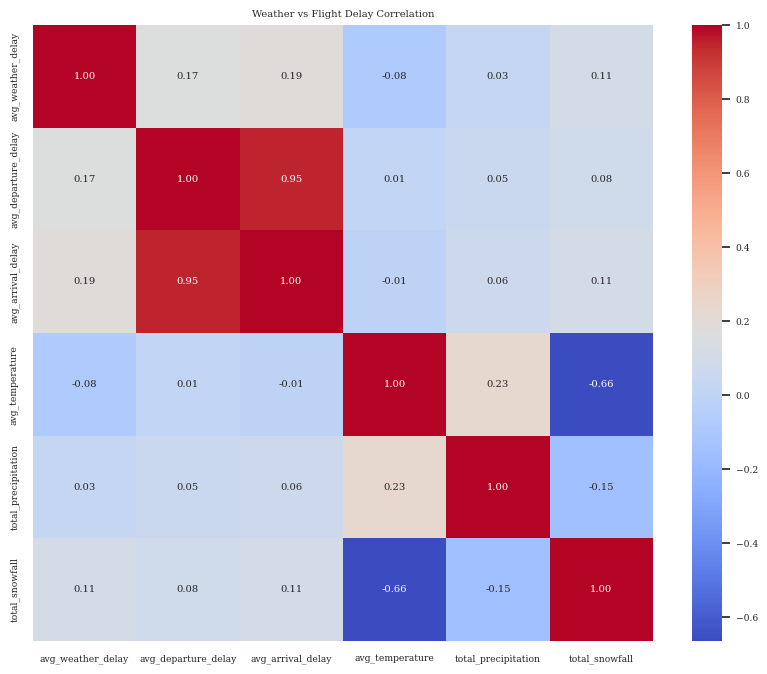

In [36]:
# Weather vs Delay Correlation Heatmap

weather_delay_cols = [
    "avg_weather_delay",
    "avg_departure_delay",
    "avg_arrival_delay",
    "avg_temperature",
    "total_precipitation",
    "total_snowfall"
]

weather_delay_corr = gold_df[
    weather_delay_cols
].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    weather_delay_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Weather vs Flight Delay Correlation")

plt.show()

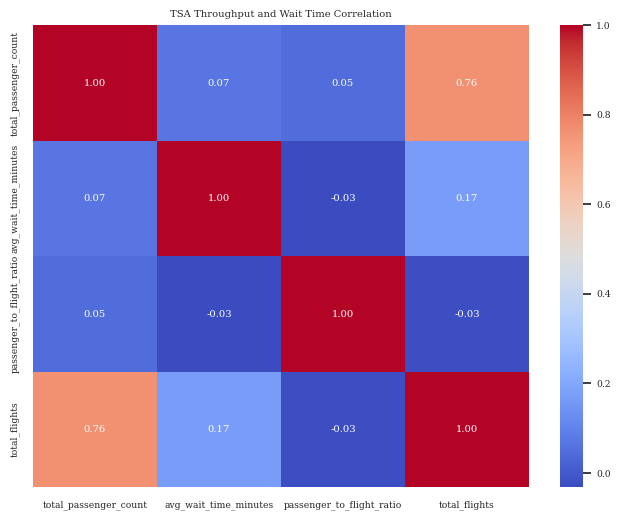

In [37]:
# TSA Throughput vs Wait Time Heatmap

tsa_cols = [
    "total_passenger_count",
    "avg_wait_time_minutes",
    "passenger_to_flight_ratio",
    "total_flights"
]

tsa_corr = gold_df[tsa_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    tsa_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("TSA Throughput and Wait Time Correlation")

plt.show()

##### Pairwise Correlation Matrix

In [23]:
# Measures the direction and strength of a relationship between two variables
#
# | Correlation | Meaning                       |
# | ----------- | ----------------------------- |
# | +1          | perfect positive relationship |
# | 0           | no relationship               |
# | -1          | perfect negative relationship |


numeric_cols = gold_df.select_dtypes(include=np.number)
corr_matrix = numeric_cols.corr()

corr_matrix

,month,total_flights,avg_departure_delay,avg_arrival_delay,delay_rate,cancellation_rate,avg_carrier_delay,avg_weather_delay,avg_nas_delay,avg_security_delay,avg_late_aircraft_delay,avg_taxi_out_time,avg_taxi_in_time,avg_total_taxi_time,total_passenger_count,avg_wait_time_minutes,avg_temperature,total_precipitation,total_snowfall,passenger_to_flight_ratio
month,1.000000,0.004169,-0.037908,-0.042994,-0.077317,-0.162510,-0.009960,-0.036476,-0.019249,0.017634,-0.049360,-0.021755,0.008150,-0.012460,-0.110892,0.024752,0.224012,0.079524,-0.227087,-0.074987
total_flights,0.004169,1.000000,0.081705,0.022602,0.166549,-0.099293,0.018314,-0.009504,-0.003078,-0.016992,-0.024153,0.276224,-0.200675,0.105048,0.762469,0.168548,0.016890,-0.060267,-0.013128,-0.027382
avg_departure_delay,-0.037908,0.081705,1.000000,0.952956,0.586236,0.164282,0.787322,0.166657,0.368817,0.031186,0.503851,0.152091,0.103008,0.174843,0.127084,0.094124,0.014444,0.054692,0.084750,-0.034666
avg_arrival_delay,-0.042994,0.022602,0.952956,1.000000,0.579467,0.195412,0.749330,0.187068,0.439553,0.040135,0.518555,0.159412,0.161157,0.211382,0.014882,0.038231,-0.012640,0.064136,0.108243,-0.042442
delay_rate,-0.077317,0.166549,0.586236,0.579467,1.000000,0.240259,0.149476,0.140792,0.365219,0.151811,0.601926,0.130991,0.073840,0.143560,0.171271,0.114594,-0.007152,0.037968,0.093639,0.011285
cancellation_rate,-0.162510,-0.099293,0.164282,0.195412,0.240259,1.000000,0.010286,0.127273,0.161147,0.003425,0.163258,0.139852,0.187427,0.210587,-0.097000,-0.035520,-0.297321,-0.021763,0.317386,-0.054801
avg_carrier_delay,-0.009960,0.018314,0.787322,0.749330,0.149476,0.010286,1.000000,0.018947,0.035090,-0.007271,0.021487,0.068409,0.049982,0.080298,0.053994,0.047052,-0.031864,0.016941,0.078560,-0.024366
avg_weather_delay,-0.036476,-0.009504,0.166657,0.187068,0.140792,0.127273,0.018947,1.000000,0.068965,-0.007546,0.038090,0.105341,0.076782,0.123555,0.008490,0.012367,-0.084070,0.027860,0.106537,-0.030915
avg_nas_delay,-0.019249,-0.003078,0.368817,0.439553,0.365219,0.161147,0.035090,0.068965,1.000000,-0.002885,0.209373,0.253716,0.227996,0.321072,-0.005219,0.002089,-0.018673,0.086337,0.112246,-0.011540
avg_security_delay,0.017634,-0.016992,0.031186,0.040135,0.151811,0.003425,-0.007271,-0.007546,-0.002885,1.000000,-0.017255,-0.063100,-0.081738,-0.093537,-0.020614,0.007551,-0.001514,-0.004863,-0.027689,-0.014297


### SECTION 6 - Time-series Trend Analysis

##### Monthly Trends

C:\Users\kyuen\AppData\Local\Temp\ipykernel_22236\3626691827.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["year", "month"])["avg_departure_delay"]


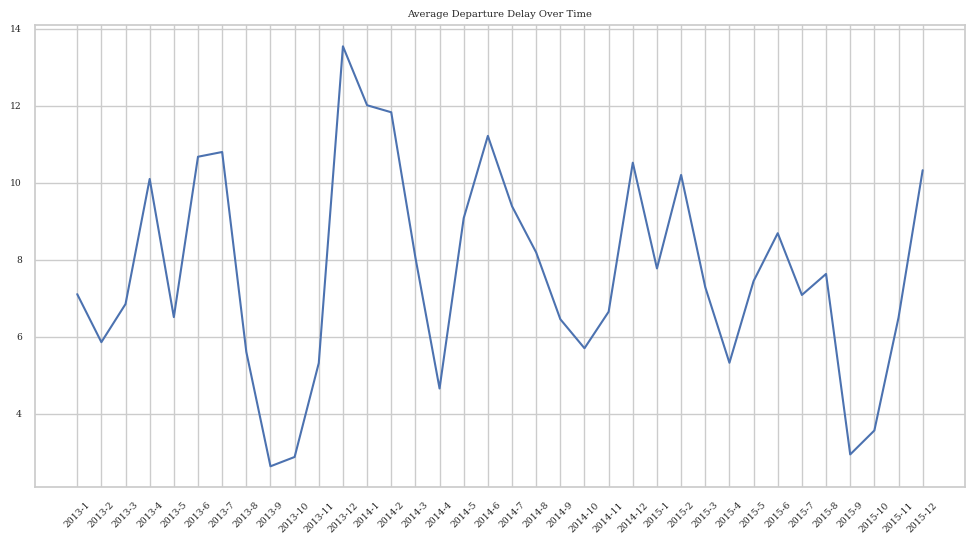

In [24]:
monthly_delay_trend = (
    gold_df
    .groupby(["year", "month"])["avg_departure_delay"]
    .mean()
    .reset_index()
)

monthly_delay_trend["year_month"] = (
    monthly_delay_trend["year"].astype(str)
    + "-"
    + monthly_delay_trend["month"].astype(str)
)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_delay_trend["year_month"],
    monthly_delay_trend["avg_departure_delay"]
)

plt.xticks(rotation=45)

plt.title("Average Departure Delay Over Time")

plt.show()

##### Seasonal Pattern

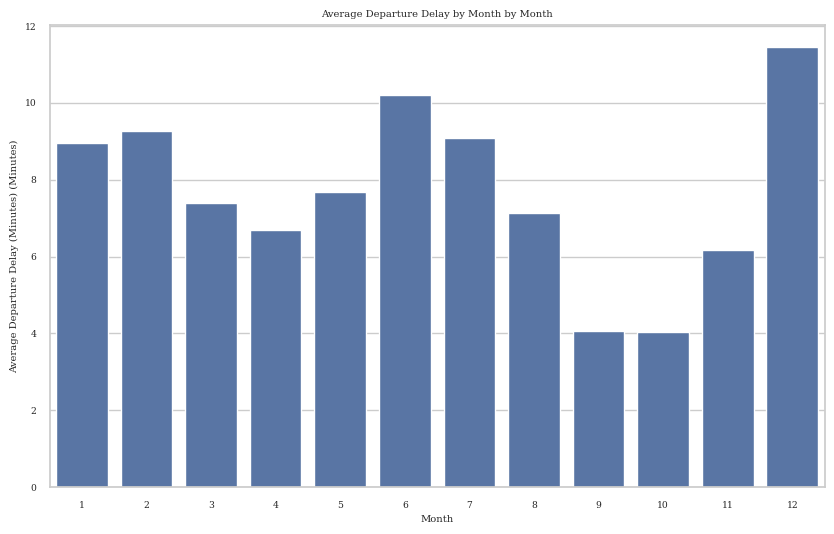

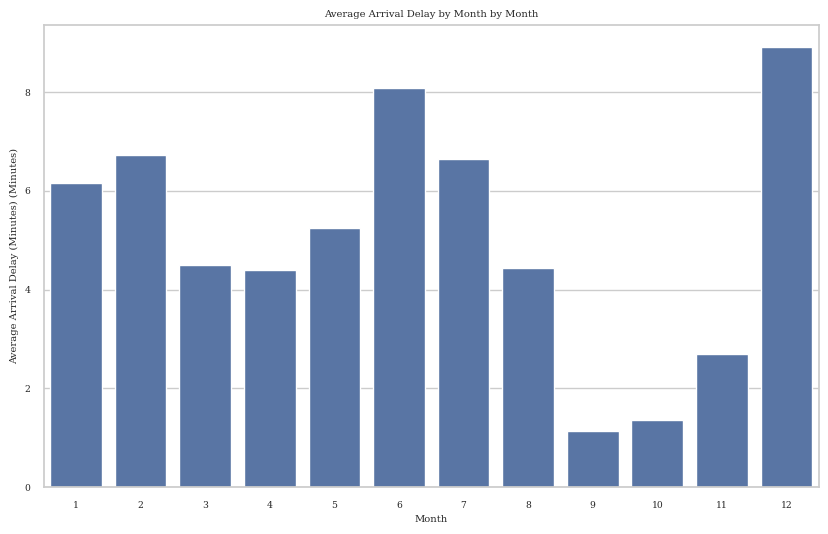

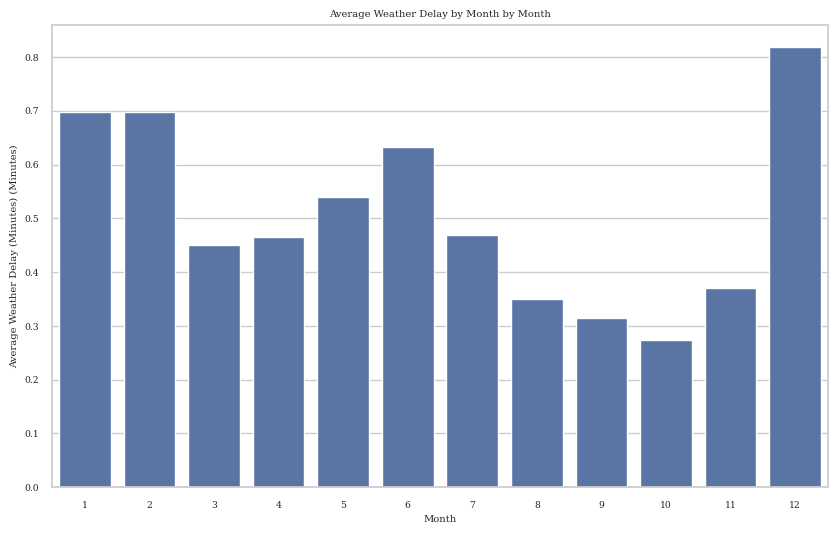

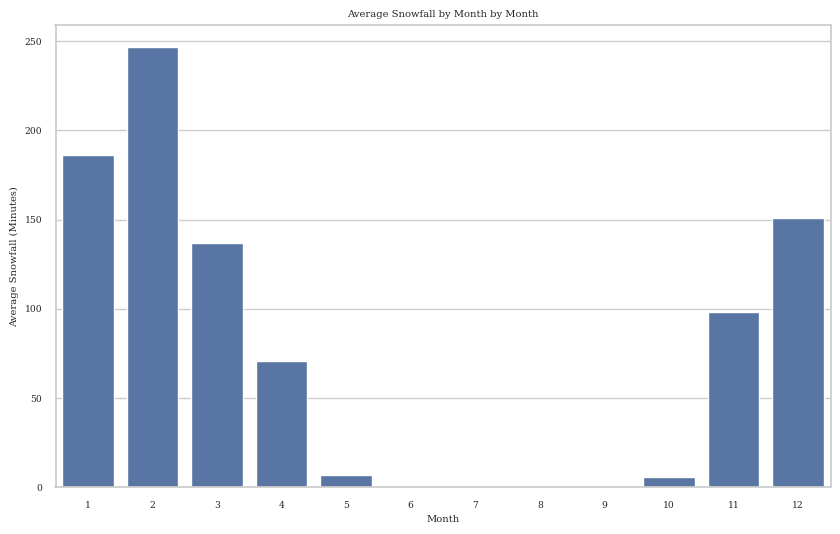

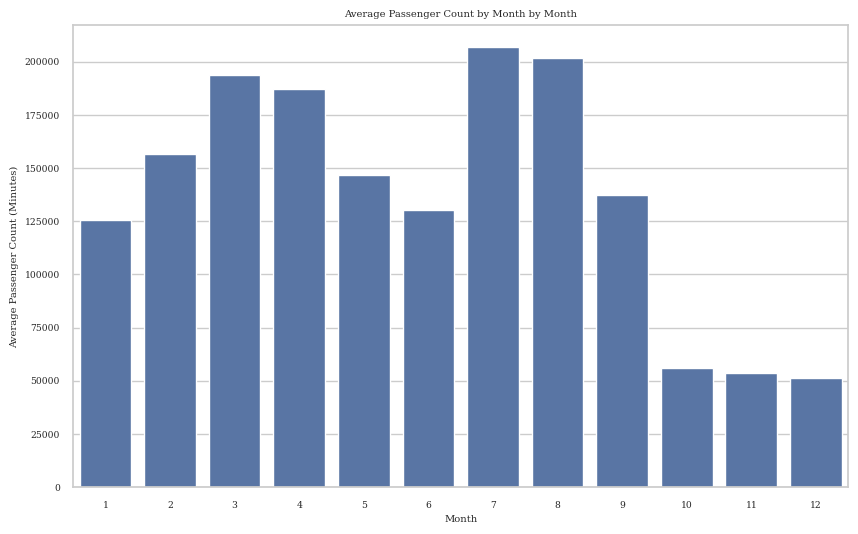

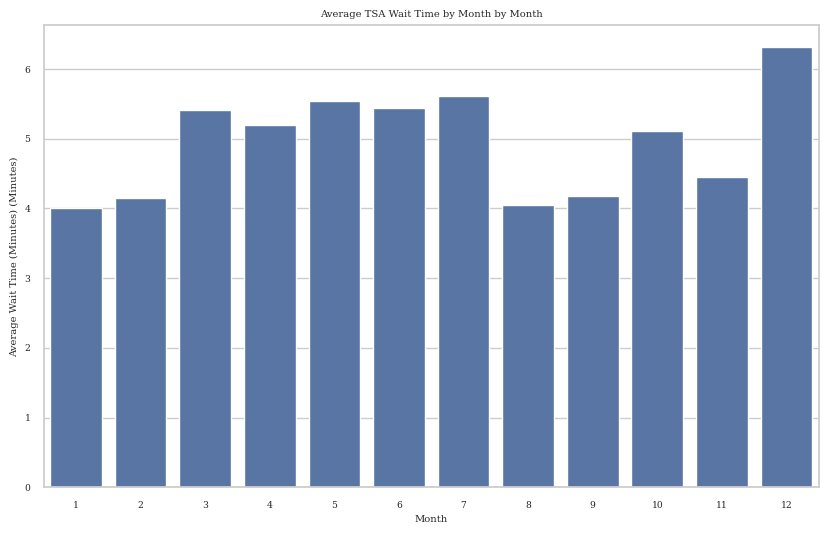

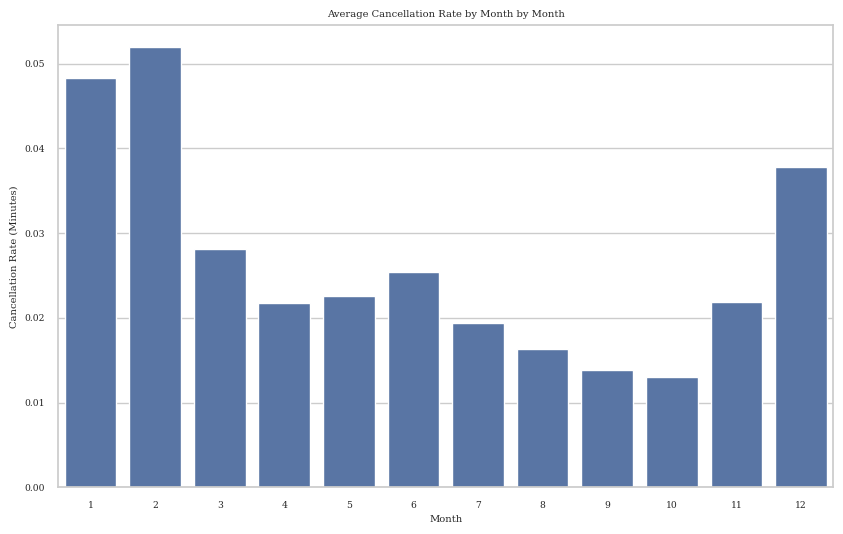

In [28]:
def seasonal_analysis(column, title, ylabel):
    monthly = (
        gold_df
        .groupby("month")[column]
        .mean()
        .reset_index()
    )
    
    plt.figure(figsize=(10, 6))
    
    sns.barplot(
        data=monthly,
        x="month",
        y=column
    )
    
    plt.title(f"{title} by Month")
    plt.xlabel("Month")
    plt.ylabel(f"{ylabel} (Minutes)")
    
    plt.show()

# Average Departure Delay by Month
seasonal_analysis("avg_departure_delay", "Average Departure Delay by Month", "Average Departure Delay (Minutes)")
# Average Arrival Delay by Month
seasonal_analysis("avg_arrival_delay", "Average Arrival Delay by Month", "Average Arrival Delay (Minutes)")
# Weather Delay by Month
seasonal_analysis("avg_weather_delay", "Average Weather Delay by Month", "Average Weather Delay (Minutes)")
# Total Snowfall by Month
seasonal_analysis("total_snowfall", "Average Snowfall by Month", "Average Snowfall")
# Passenger Throughput by Month
seasonal_analysis("total_passenger_count", "Average Passenger Count by Month", "Average Passenger Count")
# TSA Wait Time by Month
seasonal_analysis("avg_wait_time_minutes", "Average TSA Wait Time by Month", "Average Wait Time (Minutes)")
# Cancellation Rate by Month
seasonal_analysis("cancellation_rate", "Average Cancellation Rate by Month", "Cancellation Rate")

### SECTION 7 - ML Readiness

##### Multicollinearity Analysis

In [32]:
# Identify redundant features

# | VIF    | Interpretation        |
# | ------ | --------------------- |
# | 1      | no multicollinearity  |
# | 1 – 5  | low/moderate          |
# | 5 – 10 | high                  |
# | > 10   | very high/problematic |
# | >> 100 | severe redundancy     |

features = gold_df.select_dtypes(include=np.number).dropna()

vif_df = pd.DataFrame()

vif_df["feature"] = features.columns

vif_df["VIF"] = [
    variance_inflation_factor(
        features.values,
        i
    )
    for i in range(features.shape[1])
]

vif_df["VIF"] = vif_df["VIF"].round(2)

vif_df = vif_df.sort_values(by="VIF", ascending=False)

vif_df.style.format({"VIF": "{:,.2f}"})

,feature,VIF
13,avg_total_taxi_time,"22,110,842.67"
11,avg_taxi_out_time,"9,282,240.88"
12,avg_taxi_in_time,"2,873,625.60"
2,avg_departure_delay,101.17
4,delay_rate,77.22
10,avg_late_aircraft_delay,50.61
6,avg_carrier_delay,28.86
8,avg_nas_delay,18.19
3,avg_arrival_delay,16.71
0,month,10.12


##### Skewness Interpretation

In [43]:
numeric_df = gold_df.select_dtypes(include=np.number)

skewness_df = pd.DataFrame({
    "feature": numeric_df.columns,
    "skewness": numeric_df.skew().values
})

skewness_df = skewness_df.sort_values(by="skewness", ascending=False)
skewness_df

,feature,skewness
6,avg_carrier_delay,76.890031
2,avg_departure_delay,33.258054
9,avg_security_delay,32.403858
19,passenger_to_flight_ratio,28.990583
3,avg_arrival_delay,27.667586
8,avg_nas_delay,24.768129
10,avg_late_aircraft_delay,9.149964
7,avg_weather_delay,8.348674
15,avg_wait_time_minutes,7.134393
1,total_flights,4.622113


##### Scaling

In [44]:
scaling_df = pd.DataFrame({
    "feature": numeric_df.columns,
    "min": numeric_df.min().values,
    "max": numeric_df.max().values,
    "mean": numeric_df.mean().values,
    "std": numeric_df.std().values
})

scaling_df

,feature,min,max,mean,std
0,month,1.00,12.00,6.500817,3.446201
1,total_flights,1.00,32268.00,1095.863158,2635.728688
2,avg_departure_delay,-27.00,879.00,7.687095,12.391720
3,avg_arrival_delay,-27.25,880.00,5.040840,13.270410
4,delay_rate,0.00,1.00,0.163181,0.089458
5,cancellation_rate,0.00,0.78,0.026691,0.041072
6,avg_carrier_delay,0.00,891.50,3.091092,9.425688
7,avg_weather_delay,0.00,28.67,0.507132,1.415482
8,avg_nas_delay,0.00,214.50,2.680139,3.379064
9,avg_security_delay,0.00,23.25,0.032847,0.501935


##### Encoding Considerations

In [46]:
categorical_cols = gold_df.select_dtypes(exclude=np.number).columns

for col in categorical_cols:
    print(f"\n{col}")
    print(gold_df[col].nunique())


iata_code
337

year
3


##### Feature Importance Candidates

In [47]:
target_corr = corr_matrix[["delay_rate"]].sort_values(by="delay_rate", ascending=False)

target_corr

,delay_rate
delay_rate,1.000000
avg_late_aircraft_delay,0.601926
avg_departure_delay,0.586236
avg_arrival_delay,0.579467
avg_nas_delay,0.365219
cancellation_rate,0.240259
total_passenger_count,0.171271
total_flights,0.166549
avg_security_delay,0.151811
avg_carrier_delay,0.149476


### SECTION 8 - Key Findings

##### 1. Dataset Structure and Coverage

- The airport_congestion_gold dataset successfully integrates flight performance, TSA throughput, TSA wait time, airport metadata, and 
weather information into a unified analytical dataset.
- The dataset covers multiple airports across monthly periods from 2013–2015, providing sufficient temporal coverage for predictive modeling 
and trend analysis.
- Composite primary keys (iata_code, year, month) showed strong uniqueness with minimal data quality concerns.

##### 2. Data Quality Observations

- No major duplicate issues were identified in the final gold dataset.
- Null values were primarily concentrated in TSA throughput, wait time, and weather-related features, which aligns with missing upstream 
source data rather than ETL failures.
- Missing data patterns appeared systematic rather than random, particularly for smaller airports and earlier years.

##### 3. Distribution and Variability Insights
- Several operational metrics exhibited high variability, including:
  - total_flights
  - total_passenger_count
  - avg_departure_delay
  - avg_arrival_delay
- Weather-related variables such as total_snowfall and avg_weather_delay showed strong positive skewness, indicating that most airport-month 
combinations experience low weather impact while a smaller subset experiences extreme events.
- Delay-related metrics displayed significant right-skewed distributions, suggesting the presence of operational outliers and irregular 
congestion events.

##### 4. Correlation and Relationship Findings
- Strong positive correlations were observed between:
  - departure delay and arrival delay
  - total flights and passenger throughput
  - snowfall and weather delays
- TSA throughput metrics demonstrated moderate relationships with TSA wait times, suggesting that higher passenger volumes may contribute to 
congestion but are not the sole driver.
- Weather variables exhibited measurable relationships with operational delays, particularly snowfall and precipitation metrics.

##### 5. Seasonal and Temporal Patterns
- Seasonal analysis indicated observable monthly fluctuations in:
  - passenger throughput
  - total flights
  - weather-related delays
- Winter months generally showed higher snowfall and weather-related operational disruption.
- Some airports demonstrated stronger seasonal congestion patterns than others, suggesting airport-specific operational behavior.

##### 6. Multicollinearity and Feature Redundancy
- Variance Inflation Factor (VIF) analysis revealed substantial multicollinearity among delay-related features.
- Extremely high VIF values were identified for:
  - avg_total_taxi_time
  - avg_taxi_out_time
  - avg_taxi_in_time
- This indicates near-linear dependency among taxi-related metrics and suggests potential feature reduction before model training.

##### 7. Machine Learning Readiness
- Several features appear to be strong predictive candidates for congestion-related modeling, including:
  - weather delay metrics
  - snowfall
  - passenger throughput
  - wait time metrics
- Many numeric features exist on significantly different scales, indicating that feature scaling may be required for certain ML algorithms.
- Categorical features such as iata_code will require encoding during preprocessing.

### SECTION 9 - Next Steps

##### 1. Feature Engineering

The next stage of the project will focus on preparing the dataset for machine learning model development. Planned feature engineering tasks 
include:

  - handling missing values
  - encoding categorical variables (iata_code)
  - scaling and normalization of numeric features
  - outlier treatment and transformation of highly skewed variables
  - feature reduction for highly collinear variables
  - creation of temporal and seasonal features

##### 2. Feature Selection

Additional analysis will be performed to identify the most informative predictive features while minimizing redundancy and target leakage. 
This may include:

  - correlation-based feature selection
  - recursive feature elimination

##### 3. Machine Learning Pipeline Development

The prepared dataset will be used to train and evaluate multiple machine learning models for airport congestion prediction, including:

  - Linear Regression
  - Random Forest

Model evaluation metrics may include:

  - RMSE
  - R² score

depending on the final prediction target.

##### 4. Model Evaluation and Optimization

Include:

  - hyperparameter tuning
  - performance comparison across models
  - overfitting and bias-variance analysis